In [1]:
import os
os.chdir("D:/文章返修/source data/Figure_3/Panel_B")
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
import pandas as pd

In [2]:
def apa(matrix, loop, s, e, lens, res, types = 'loop'):
    loop = np.array(loop, dtype = [('S','<i4'),('E','<i4'),('value','<f8')])
    ma_lens = lens*2 + 1
    ma = np.zeros([ma_lens, ma_lens])
    count = 0
    out_data = []
    for i in range(loop.shape[0]):
        start = int(loop['S'][i] / res )
        end = int(loop['E'][i] / res)
        if start <= lens or end >= (matrix.shape[0] - lens):
             continue
        if  (end - start) > s/res  and (end - start)  < e/res:
            apa_ma = matrix[(start - lens) :(start + lens + 1),(end - lens):(end + lens + 1)]
            # means = np.hstack([apa_ma[:lens,:lens],apa_ma[-lens:,-lens:]]).mean()
            
            ma += apa_ma
           # out_data.extend(list(matrix[(start-2):(start+3),(end-2):(end+3)].ravel()))
            if types == 'loop':
                out_data.append(apa_ma[lens-1:lens+2, lens-1:lens+2].mean())
            elif types == 'stem':
                out_data.append(apa_ma[np.arange(lens-lens,lens+lens+1)[1:-1],np.arange(lens-lens,lens+lens+1)[1:-1][::-1]].mean())
                out_data.append(apa_ma[np.arange(lens-lens+1,lens+lens+2)[1:-1],np.arange(lens-lens+1,lens+lens+2)[1:-1][::-1]].mean())
                out_data.append(apa_ma[np.arange(lens-lens-1,lens+lens)[1:-1],np.arange(lens-lens-1,lens+lens)[1:-1][::-1]].mean())
            elif types == 'diag':
                out_data.append( apa_ma[ np.arange(lens-lens,lens+lens+1)[1:-1], np.arange(lens-lens,lens+lens+1)[1:-1] ].mean() )
                out_data.append( apa_ma[ np.arange(lens-lens+1,lens+lens+2)[1:-1], np.arange(lens-lens+1,lens+lens+2)[1:-1] ].mean() )
                out_data.append( apa_ma[ np.arange(lens-lens-1,lens+lens)[1:-1], np.arange(lens-lens-1,lens+lens)[1:-1] ].mean() )
            count += 1
    return ma, count, out_data

def classify_rna_data(input_rna, dis, freq, binsize, discard):
    data = input_rna.copy()
    distance = data['E'] - data['S']
    rna_long = data[distance >= dis]
    rna_long_hf = rna_long[rna_long['value'] > freq]
    
    mask_c = (rna_long_hf['S'] <= discard[0]) & (rna_long_hf['value']>discard[1])
    
    hist_data = []
    s = 0
    e = binsize
    lens = data['E'].max()
    while True:
        distance_hf = rna_long_hf[~mask_c]['E'] - rna_long_hf[~mask_c]['S']
        mask = (distance_hf > s) & (distance_hf <= e)
        hist_data.append(rna_long_hf[~mask_c]['value'][mask].sum())
        s = e
        e += binsize
        if e >= lens:
            break
    
    return rna_long_hf[mask_c], rna_long_hf[~mask_c], hist_data

def get_matrix_npz(M1,M2):
    '''
    transform a three tuple into a matrix
    '''
    S1 = sparse.coo_matrix((M1['value'],(np.asarray(M1['S'], dtype='<i4'),np.asarray(M1['E'], dtype= '<i4')))).toarray()
    S2 = sparse.coo_matrix((M2['value'],(np.asarray(M2['E'], dtype='<i4'),np.asarray(M2['S'], dtype= '<i4')))).toarray()
    matrix = np.zeros((max(S2.shape),max(S1.shape)))
    matrix[np.nonzero(S1)] = S1[np.nonzero(S1)]
    matrix[np.nonzero(S2)] = S2[np.nonzero(S2)]
    return matrix

def extract_matrix(file_dir, file_name, res):
    data = np.loadtxt(file_dir + file_name, usecols=[0,1,2], dtype=[('S','<i4'),('E','<i4'),('value','<f8')])
    data['S'] = data['S'] / res
    data['E'] = data['E'] / res
    data['value'][data['value'] < 0] = 0
    data['value'][np.isnan(data['value'])] = 0
    mat = get_matrix_npz(data, data)
    return mat

def apa_plot(ma, count, l1, l2, vmax, cb = 'Reds', types = 'c'):
    plt.imshow(ma / count, cmap = plt.get_cmap(cb), vmax = vmax, vmin = 0)
    #plt.colorbar(location = 'top', shrink = 0.5)
    plt.xticks([0,10,20],["5'",'junction sites',"3'"])
    plt.yticks([0,10,20],["5'",'junction\n sites',"3'"], rotation = 0)
    if types == 'c':
        plt.title('canonical junction')
    elif types == 'short':      
        plt.title('distance < '+str(l1)+' bp')
    elif types == 'mid':      
        plt.title(str(l1)+'bp < distance < '+str(l2)+' bp')
    elif types == 'long':      
        plt.title('distance > '+str(l2)+' bp')
    else:
        plt.title('')

res = 5
file_dir = "./"
color_bar = 'Reds'

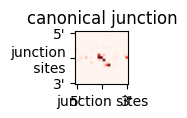

In [5]:
l1 = 1700
l2 = 22000
plt.subplot(6,4,12)
ma_pedv_ric_cell = extract_matrix(file_dir, 'PEDV_in_cell-none-5nt.matrix', res)
rna_pedv_cell_all = np.loadtxt(file_dir + '1_alpha_PEDV-14_PRJCA026550-rnaseq.1nt.none.matrix', usecols=[0,1,2], dtype=[('S','<i4'),('E','<i4'),('value','<f8')])
rna_c, rna_nc, hist_data = classify_rna_data(rna_pedv_cell_all, 100, 10, 100, [100,2000])
ma, count, data = apa(ma_pedv_ric_cell, rna_c, 0, 30000, 10, res, 'diag')
apa_plot(ma, count, l1, l2, 5, color_bar, 'c')

In [6]:
matrix = ma / count
pd.DataFrame(
    matrix,
    index=[f'R{i}' for i in range(matrix.shape[0])],
    columns=[f'C{j}' for j in range(matrix.shape[1])]
).to_excel('PEDV.xlsx', index=True)

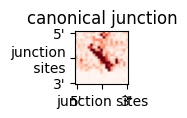

In [7]:
l1 = 2500
l2 = 20000
ma_sars_ric_cell_kr = extract_matrix(file_dir, 'virus.inCell.Vero.5nt.KR.matrix', res)
rna_seq_24_all = np.loadtxt(file_dir + '2_beta_SARS-CoV-2-9_all-rep-rna.1nt.none.matrix', usecols=[0,1,2], dtype=[('S','<f8'),('E','<f8'),('value','<f8')])
rna_c, rna_nc, hist_data = classify_rna_data(rna_seq_24_all, 100, 10, 100, [100, 2000])
plt.subplot(6,4,12)
ma, count, data = apa(ma_sars_ric_cell_kr, rna_c, 0, 30000, 10, res, 'diag')
apa_plot(ma, count, l1, l2, 5, color_bar, 'c')

In [8]:
matrix = ma / count
pd.DataFrame(
    matrix,
    index=[f'R{i}' for i in range(matrix.shape[0])],
    columns=[f'C{j}' for j in range(matrix.shape[1])]
).to_excel('SARS-CoV-2.xlsx', index=True)

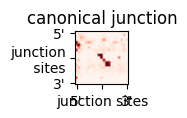

In [9]:
l1 = 1200
l2 = 25000
ma_mers_com_cell = extract_matrix(file_dir, 'MERS-comrades-PRJNA646969-Huh7-20h-gRNA-KR-5BP.matrix', res)
rna_seq_mers = np.loadtxt(file_dir + '2_beta_MERS-CoV-2_PRJNA279442-48h.1nt.none.matrix', usecols=[0,1,2], dtype=[('S','<i4'),('E','<i4'),('value','<f8')])
rna_c, rna_nc, hist_data = classify_rna_data(rna_seq_mers, 100, 10, 100, [100,1000])
plt.subplot(6,4,12)
ma, count, data  = apa(ma_mers_com_cell, rna_c, 0, 30000, 10, res,'diag')
apa_plot(ma, count, l1, l2, 5, color_bar, 'c')

In [10]:
matrix = ma / count
pd.DataFrame(
    matrix,
    index=[f'R{i}' for i in range(matrix.shape[0])],
    columns=[f'C{j}' for j in range(matrix.shape[1])]
).to_excel('MERS-CoV.xlsx', index=True)

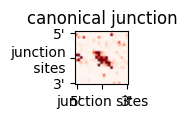

In [ ]:
line_1 = 2100
line_2 = 18750
ma_ric_pdcov_cell = extract_matrix(file_dir, 'pdcov_in_Cell.5nt.KR.matrix', res)
rna_pdcov_cell_all = np.loadtxt(file_dir + '4_delta_PDCoV-1_PRJCA026550-rnaseq.1nt.none.matrix', usecols=[0,1,2], dtype=[('S','<f8'),('E','<f8'),('value','<f8')])
rna_c, rna_nc, hist_data = classify_rna_data(rna_pdcov_cell_all, 15, 10, 100, [100,2000])
plt.subplot(6,4,12)
ma, count, data = apa(ma_ric_pdcov_cell, rna_c, 0, 30000, 10, res, 'diag')
apa_plot(ma, count, line_1, line_2, 5, color_bar, 'c')

In [4]:
matrix = ma / count
pd.DataFrame(
    matrix,
    index=[f'R{i}' for i in range(matrix.shape[0])],
    columns=[f'C{j}' for j in range(matrix.shape[1])]
).to_excel('PDCoV.xlsx', index=True)